In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [10]:
df= pd.read_csv('../Data/Historical Product Demand.csv')


In [11]:
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012/7/27,100
1,Product_0979,Whse_J,Category_028,2012/1/19,500
2,Product_0979,Whse_J,Category_028,2012/2/3,500
3,Product_0979,Whse_J,Category_028,2012/2/9,500
4,Product_0979,Whse_J,Category_028,2012/3/2,500


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Product_Code      1048575 non-null  object
 1   Warehouse         1048575 non-null  object
 2   Product_Category  1048575 non-null  object
 3   Date              1037336 non-null  object
 4   Order_Demand      1048575 non-null  object
dtypes: object(5)
memory usage: 40.0+ MB


- Las fechas estan en formato incorrecto
- Existen nulos en card

In [13]:
df.isnull().sum()

Product_Code            0
Warehouse               0
Product_Category        0
Date                11239
Order_Demand            0
dtype: int64

In [14]:
df[df['Date'].isna()]

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
45460,Product_1461,Whse_A,Category_019,NaN,10000
456373,Product_1636,Whse_A,Category_019,NaN,100
456374,Product_1461,Whse_A,Category_019,NaN,300
456375,Product_1464,Whse_A,Category_019,NaN,300
456376,Product_1388,Whse_A,Category_019,NaN,200
...,...,...,...,...,...
995790,Product_1464,Whse_A,Category_019,NaN,(900)
995791,Product_1541,Whse_A,Category_019,NaN,(200)
995792,Product_1388,Whse_A,Category_019,NaN,(300)
995793,Product_1541,Whse_A,Category_019,NaN,(300)


- Existen bastantes nulos los que eliminaremos
- Además también existen otros carácteres que no son números

In [15]:
df.dropna(axis=0, inplace=True)

In [16]:
df.isnull().sum()

Product_Code        0
Warehouse           0
Product_Category    0
Date                0
Order_Demand        0
dtype: int64

In [17]:
df['Order_Demand'] = df['Order_Demand'].str.replace(r'[^0-9]', '', regex=True).astype(int)


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1037336 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Product_Code      1037336 non-null  object
 1   Warehouse         1037336 non-null  object
 2   Product_Category  1037336 non-null  object
 3   Date              1037336 non-null  object
 4   Order_Demand      1037336 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 47.5+ MB


In [19]:
df['Date'] = pd.to_datetime(df['Date'])

In [20]:
df.set_index('Date', inplace=True)

In [21]:
df.describe().round(2)

,Order_Demand
count,1037336.00
mean,4949.38
std,29073.44
min,0.00
25%,20.00
50%,300.00
75%,2000.00
max,4000000.00


In [22]:
df = df[~(df['Order_Demand']==0)]

df

,Product_Code,Warehouse,Product_Category,Order_Demand
Date,,,,
2012-07-27,Product_0993,Whse_J,Category_028,100
2012-01-19,Product_0979,Whse_J,Category_028,500
2012-02-03,Product_0979,Whse_J,Category_028,500
2012-02-09,Product_0979,Whse_J,Category_028,500
2012-03-02,Product_0979,Whse_J,Category_028,500
...,...,...,...,...
2016-04-27,Product_1791,Whse_J,Category_006,1000
2016-04-27,Product_1974,Whse_J,Category_006,1
2016-04-28,Product_1787,Whse_J,Category_006,2500


In [23]:
df = df[df.index.year > 2012]

In [24]:
y = df['Order_Demand'].resample('W-MON').mean()




In [25]:
y

Date
2013-01-07    7692.771510
2013-01-14    4896.997800
2013-01-21    5422.505071
2013-01-28    4560.791838
2013-02-04    5051.730213
                 ...     
2016-12-12    5147.452025
2016-12-19    5178.351050
2016-12-26    5794.505874
2017-01-02    5653.688689
2017-01-09    5671.096154
Freq: W-MON, Name: Order_Demand, Length: 210, dtype: float64

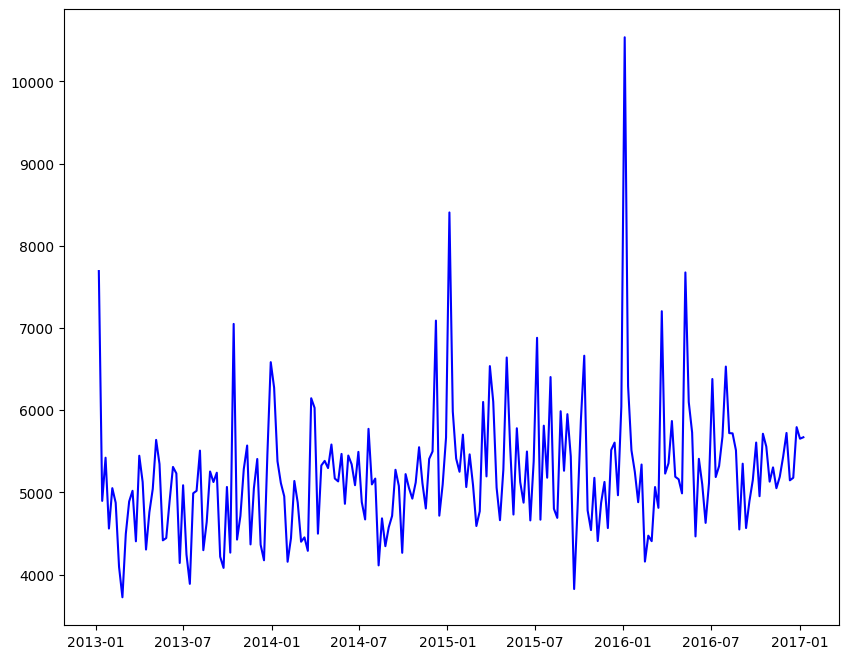

In [26]:
plt.figure(figsize=(10, 8))
plt.plot(y.index, y, label='Datos Originales', color='blue')
plt.show()


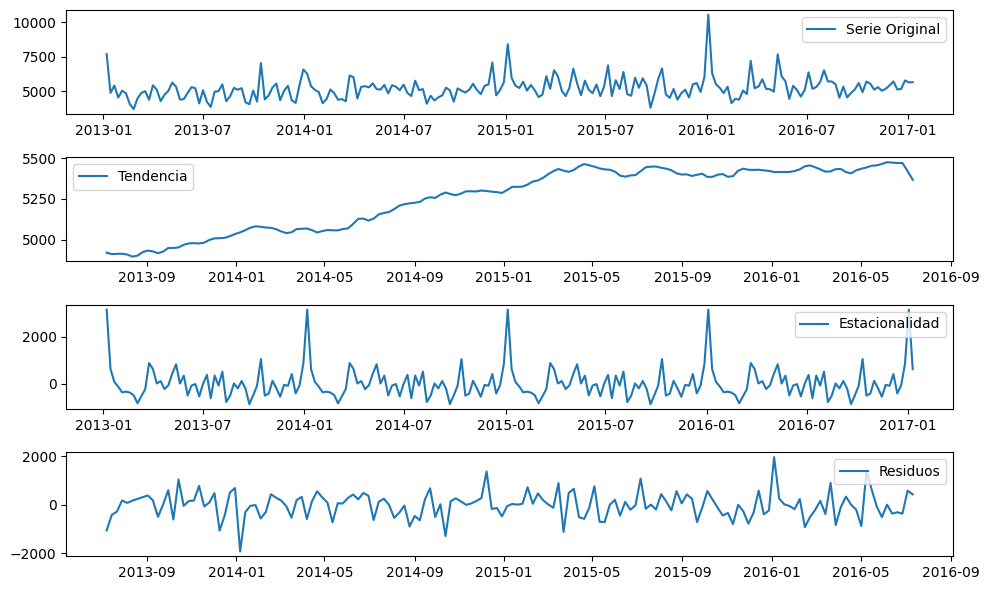

In [27]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(y, model='additive')

# Graficar los componentes
plt.figure(figsize=(10, 6))
plt.subplot(4, 1, 1)
plt.plot(y, label='Serie Original')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(result.trend, label='Tendencia')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(result.seasonal, label='Estacionalidad')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(result.resid, label='Residuos')
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
from statsmodels.tsa.stattools import adfuller

# Realizar el test de Dickey-Fuller
result = adfuller(y.values)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: -11.833485215442721
p-value: 7.890088292120355e-22
Critical Values: {'1%': np.float64(-3.4620315036789666), '5%': np.float64(-2.8754705024827127), '10%': np.float64(-2.5741950726860647)}


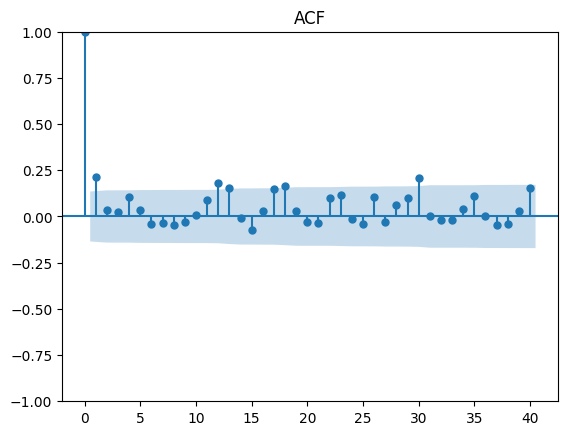

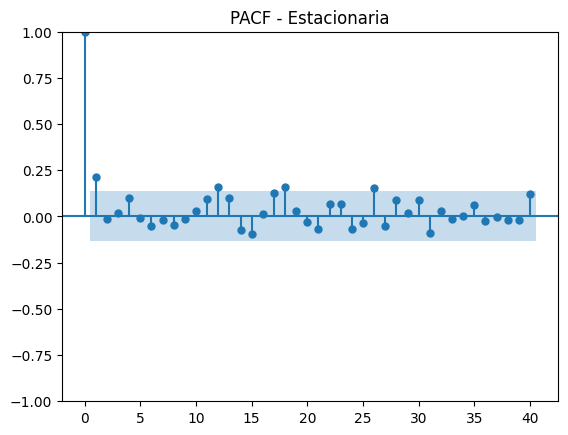

In [29]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_pacf

plot_acf(y,  title="ACF", lags='40')
plt.show()
plot_pacf(y, title="PACF - Estacionaria", lags='40')
plt.show()

In [31]:
from statsmodels.tsa.stattools import adfuller

# Realizar la prueba de Dickey-Fuller
adf_result = adfuller(y)
print(f'Estadístico ADF: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')

Estadístico ADF: -11.833485215442721
p-value: 7.890088292120355e-22


In [37]:
import statsmodels.api as sm

model = sm.tsa.SARIMAX(y, order=(1, 0, 1), seasonal_order= (1, 1, 0, 52))
results = model.fit()

# Pronóstico para los próximos 'n' pasos
n_pronostico = 52 # Ejemplo: pronóstico para las próximas 52 semanas
pronostico_sarima = results.get_forecast(steps=n_pronostico)
pronostico_intervalo = pronostico_sarima.conf_int()


c:\Proyectos\Pj_1\myenv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


2017-01-16    5749.810348
2017-01-23    5016.219988
2017-01-30    5187.884617
2017-02-06    5098.489647
2017-02-13    4493.546771
2017-02-20    4342.265806
2017-02-27    4610.495563
2017-03-06    4859.933950
2017-03-13    5109.927702
2017-03-20    6842.347114
2017-03-27    5513.596622
2017-04-03    5285.787214
2017-04-10    5925.149057
2017-04-17    5005.571702
2017-04-24    5297.280566
2017-05-01    5035.642873
2017-05-08    7578.289549
2017-05-15    5853.125289
2017-05-22    5837.534785
2017-05-29    4432.961107
2017-06-05    5449.115913
2017-06-12    5049.150944
2017-06-19    4717.850876
2017-06-26    5057.605663
2017-07-03    6507.770466
2017-07-10    5061.417619
2017-07-17    5440.922794
2017-07-24    5562.290772
2017-07-31    6582.224327
2017-08-07    5568.278493
2017-08-14    5673.071140
2017-08-21    5504.898125
2017-08-28    4673.988989
2017-09-04    5360.145619
2017-09-11    4702.459564
2017-09-18    4740.742046
2017-09-25    5158.291685
2017-10-02    5592.767844
2017-10-09  

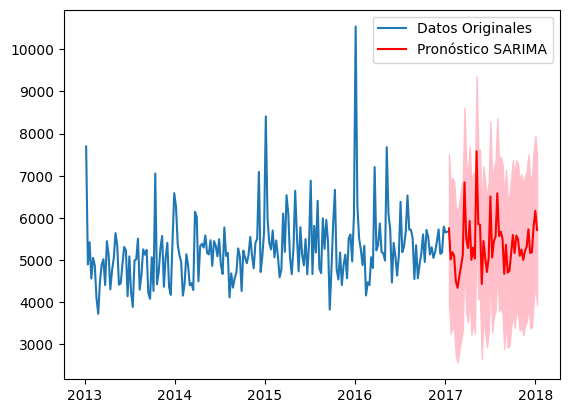

In [38]:
# Imprimir los pronósticos
print(pronostico_sarima.predicted_mean)
print(pronostico_intervalo)

# Puedes graficar los pronósticos y los datos originales si lo deseas
import matplotlib.pyplot as plt

plt.plot(y, label='Datos Originales')
plt.plot(pronostico_sarima.predicted_mean, color='red', label='Pronóstico SARIMA')
plt.fill_between(pronostico_intervalo.index, pronostico_intervalo.iloc[:, 0], pronostico_intervalo.iloc[:, 1], color='pink')
plt.legend()
plt.show()